# Rice Leaf Disease Classification: Custom CNN vs Pre-trained Models
In this notebook, we compare the performance of a custom CNN built from scratch against 5 popular pre-trained models:
1. **Custom CNN**
2. **ResNet18**
3. **VGG16**
4. **EfficientNet-B0**
5. **DenseNet121**
6. **MobileNetV2**

The task is to classify images into three categories of rice leaf diseases: Bacterial leaf blight, Brown spot, and Leaf smut.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import os
import time
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Configuration
DATA_DIR = r"c:\Users\Gaurav Srivastava\Desktop\College\SEM 6\DL\PROJECT\data"
BATCH_SIZE = 16
NUM_EPOCHS = 10
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")


Using device: cuda


In [3]:
# Data Augmentation & Preprocessing
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load full dataset
full_dataset = datasets.ImageFolder(DATA_DIR)
classes = full_dataset.classes
print(f"Detected classes: {classes}")
num_classes = len(classes)

# Split dataset (70% train, 15% val, 15% test)
n_total = len(full_dataset)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_data, val_data, test_data = random_split(full_dataset, [n_train, n_val, n_test])

class TransformedDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

train_loader = DataLoader(TransformedDataset(train_data, train_transforms), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TransformedDataset(val_data, val_test_transforms), batch_size=BATCH_SIZE)
test_loader = DataLoader(TransformedDataset(test_data, val_test_transforms), batch_size=BATCH_SIZE)

print(f"Training samples: {len(train_data)}, Validation: {len(val_data)}, Test: {len(test_data)}")


Detected classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
Training samples: 84, Validation: 18, Test: 18


In [4]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Conv Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Conv Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [5]:
def get_model(model_name, num_classes):
    if model_name == "custom":
        model = CustomCNN(num_classes)
    elif model_name == "resnet18":
        model = models.resnet18(weights='DEFAULT')
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == "vgg16":
        model = models.vgg16(weights='DEFAULT')
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights='DEFAULT')
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == "densenet121":
        model = models.densenet121(weights='DEFAULT')
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == "mobilenet_v2":
        model = models.mobilenet_v2(weights='DEFAULT')
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown model: {model_name}")
    
    return model.to(DEVICE)


In [6]:
def train_evaluate(model_name, model, train_loader, val_loader, test_loader, epochs=NUM_EPOCHS):
    print(f"\n{'='*40}\nTraining {model_name}\n{'='*40}")
    
    criterion = nn.CrossEntropyLoss()
    # Different learning rates: pre-trained models often do better with a smaller LR for fine-tuning
    lr = LEARNING_RATE if model_name == "custom" else LEARNING_RATE * 0.1
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_wts = model.state_dict()
    
    start_time = time.time()
    
    for epoch in range(epochs):
        # Training Phase
        model.train()
        running_loss, running_corrects = 0.0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        
        # Validation Phase
        model.eval()
        val_loss, val_corrects = 0.0, 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
                
        val_epoch_loss = val_loss / len(val_loader.dataset)
        val_epoch_acc = val_corrects.double() / len(val_loader.dataset)
        
        history['train_loss'].append(epoch_loss)
        history['val_loss'].append(val_epoch_loss)
        history['train_acc'].append(epoch_acc.item())
        history['val_acc'].append(val_epoch_acc.item())
        
        if val_epoch_acc > best_val_acc:
            best_val_acc = val_epoch_acc
            best_model_wts = model.state_dict()
            
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}")

    time_elapsed = time.time() - start_time
    print(f"{model_name} Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    
    # Load best weights for test evaluation
    model.load_state_dict(best_model_wts)
    model.eval()
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    test_acc = accuracy_score(all_labels, all_preds)
    print(f"{model_name} Test Accuracy: {test_acc:.4f}")
    
    return history, test_acc, all_labels, all_preds


In [7]:
models_to_test = ["custom", "resnet18", "vgg16", "efficientnet_b0", "densenet121", "mobilenet_v2"]

all_histories = {}
all_test_acc = {}
all_predictions = {}

for m_name in models_to_test:
    model = get_model(m_name, num_classes)
    hist, t_acc, true_labels, preds = train_evaluate(m_name, model, train_loader, val_loader, test_loader, epochs=NUM_EPOCHS)
    
    all_histories[m_name] = hist
    all_test_acc[m_name] = t_acc
    all_predictions[m_name] = preds
    
true_labels_for_eval = true_labels # True labels are the same across models



Training custom
Epoch 1/10 | Train Loss: 29.8479 Acc: 0.4048 | Val Loss: 12.2866 Acc: 0.2778
Epoch 2/10 | Train Loss: 25.6091 Acc: 0.3571 | Val Loss: 4.9020 Acc: 0.2778
Epoch 3/10 | Train Loss: 16.3778 Acc: 0.4762 | Val Loss: 7.5627 Acc: 0.5556
Epoch 4/10 | Train Loss: 14.1770 Acc: 0.4762 | Val Loss: 20.6467 Acc: 0.2778
Epoch 5/10 | Train Loss: 20.0569 Acc: 0.4048 | Val Loss: 12.0923 Acc: 0.5000
Epoch 6/10 | Train Loss: 9.3960 Acc: 0.4762 | Val Loss: 11.1438 Acc: 0.5000
Epoch 7/10 | Train Loss: 10.1446 Acc: 0.5476 | Val Loss: 6.1931 Acc: 0.4444
Epoch 8/10 | Train Loss: 6.2978 Acc: 0.5119 | Val Loss: 2.7452 Acc: 0.3889
Epoch 9/10 | Train Loss: 6.2393 Acc: 0.4405 | Val Loss: 3.5579 Acc: 0.2778
Epoch 10/10 | Train Loss: 3.1811 Acc: 0.5000 | Val Loss: 1.6553 Acc: 0.3333
custom Training complete in 0m 22s
custom Test Accuracy: 0.6111

Training resnet18
Epoch 1/10 | Train Loss: 1.2582 Acc: 0.3929 | Val Loss: 0.6777 Acc: 0.7778
Epoch 2/10 | Train Loss: 0.7793 Acc: 0.5952 | Val Loss: 0.4262 A

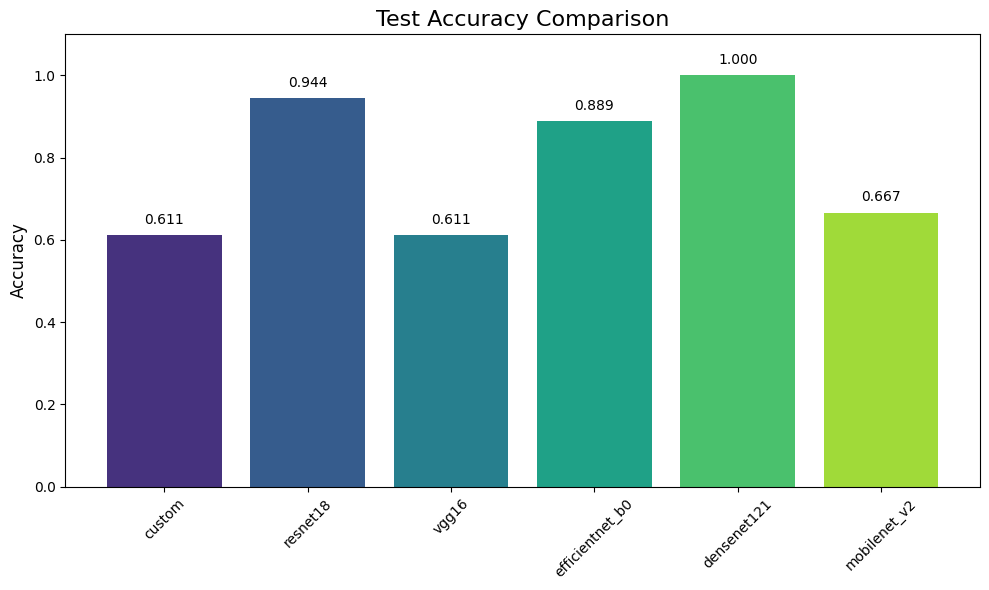

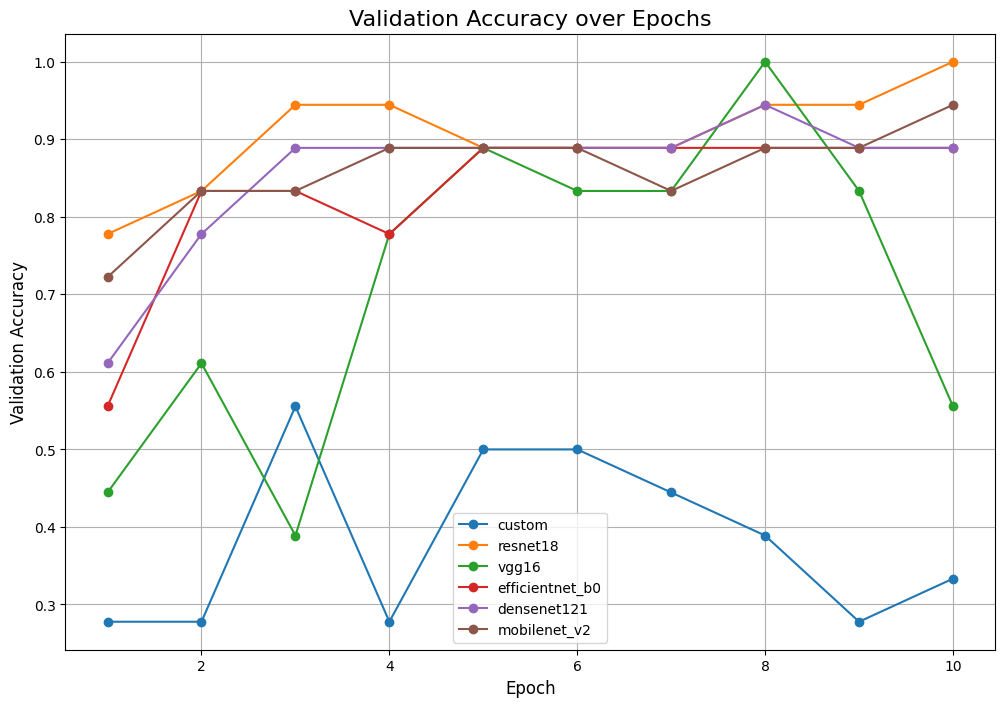

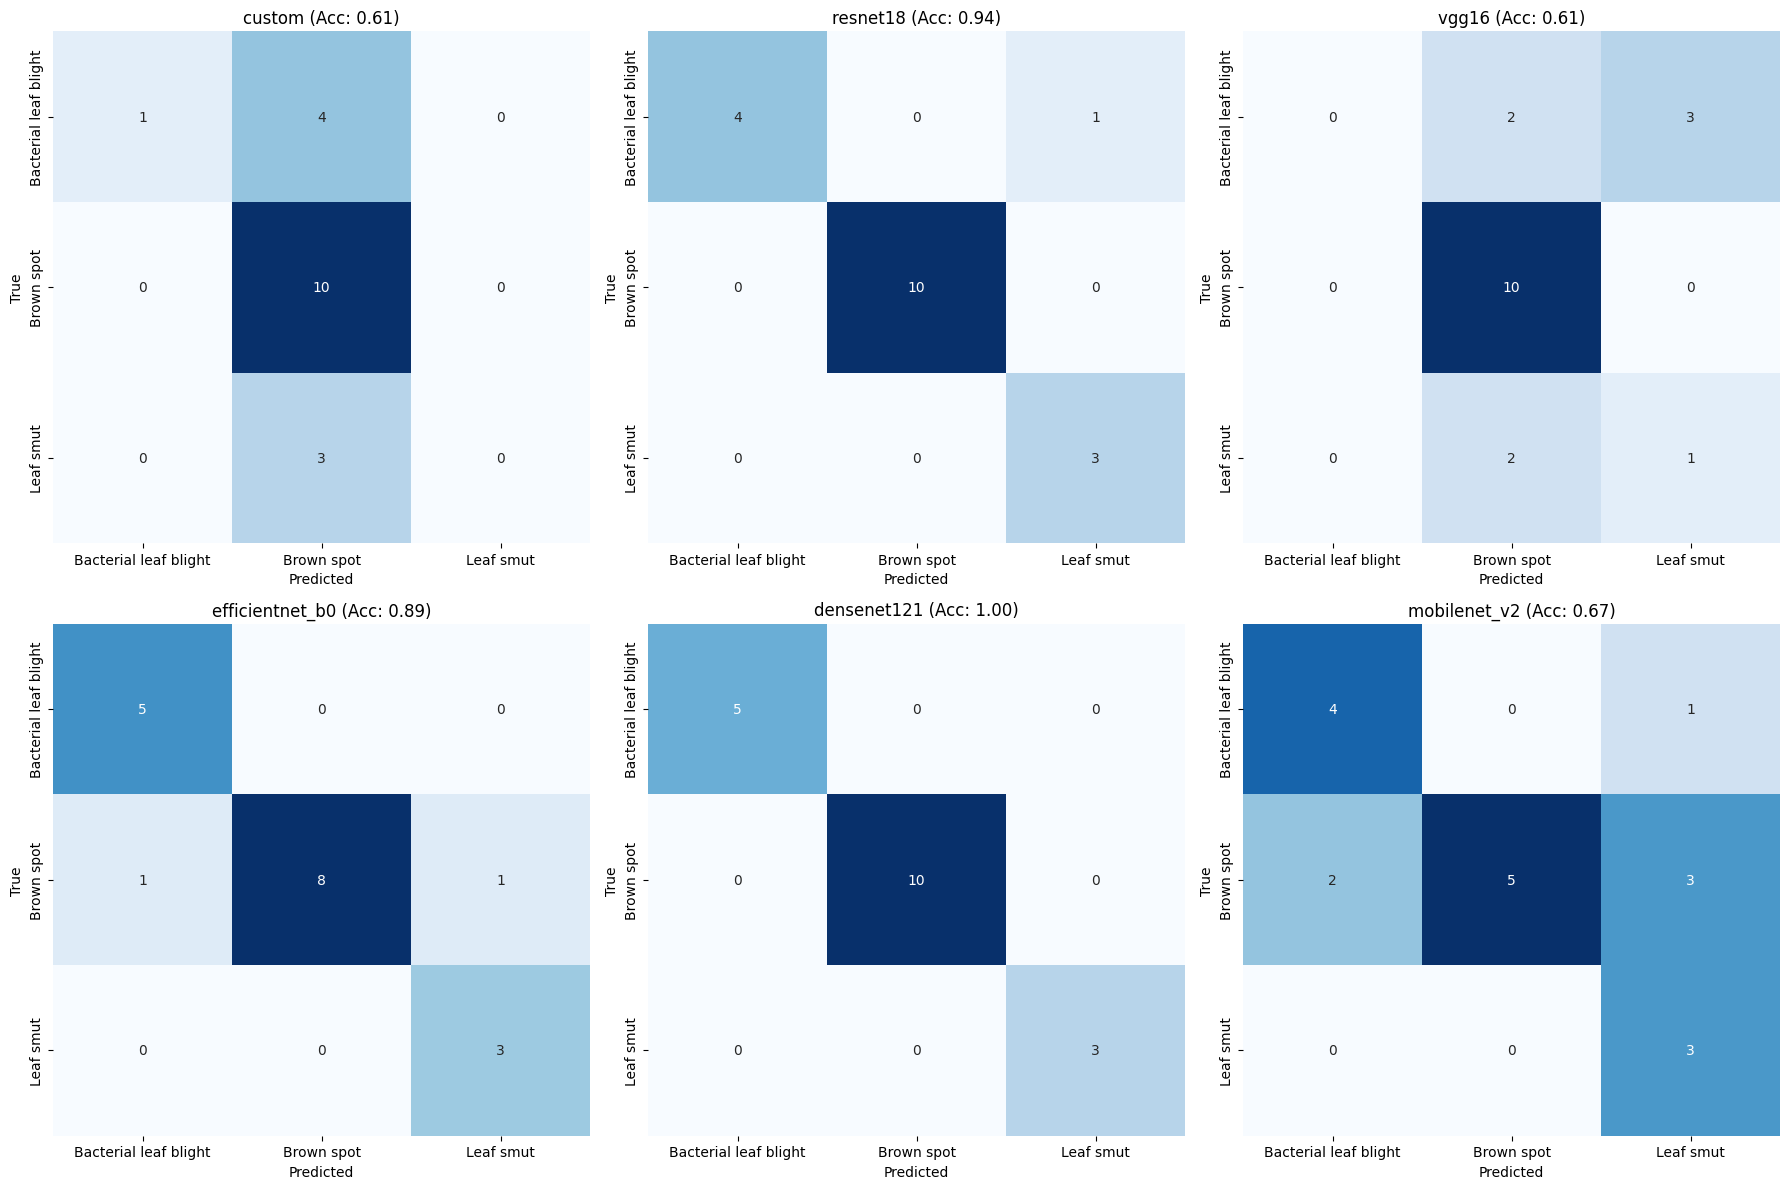

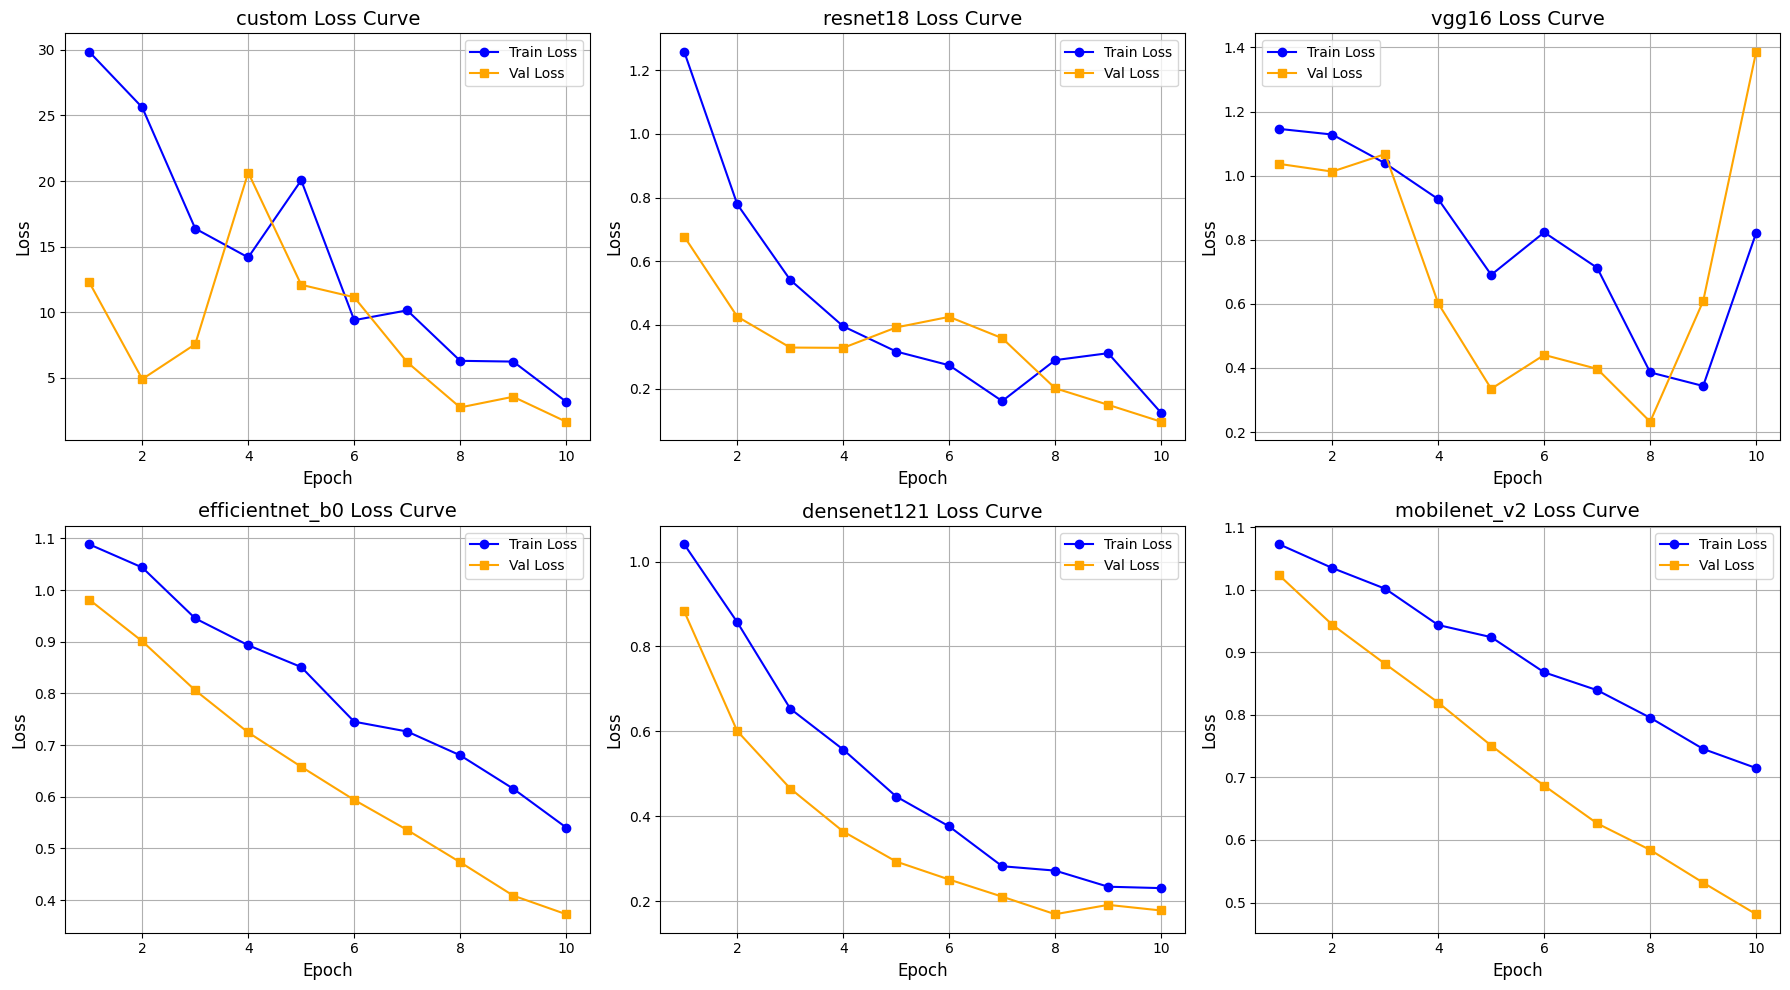

In [10]:
# 1. Bar Chart of Test Accuracies
plt.figure(figsize=(10, 6))
bars = plt.bar(all_test_acc.keys(), all_test_acc.values(), color=sns.color_palette("viridis", len(models_to_test)))
plt.title('Test Accuracy Comparison', fontsize=16)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1.1)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Validation Accuracy Curves
plt.figure(figsize=(12, 8))
for m_name, hist in all_histories.items():
    plt.plot(range(1, NUM_EPOCHS + 1), hist['val_acc'], marker='o', label=m_name)
plt.title('Validation Accuracy over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# 3. Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, m_name in enumerate(models_to_test):
    cm = confusion_matrix(true_labels_for_eval, all_predictions[m_name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{m_name} (Acc: {all_test_acc[m_name]:.2f})')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()
plt.show()

# Create a single figure with a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, m_name in enumerate(models_to_test):
    hist = all_histories[m_name]
    
    # Plot Training and Validation Loss for the specific model
    axes[idx].plot(range(1, NUM_EPOCHS + 1), hist['train_loss'], label='Train Loss', marker='o', color='blue')
    axes[idx].plot(range(1, NUM_EPOCHS + 1), hist['val_loss'], label='Val Loss', marker='s', color='orange')
    
    # Formatting the subplot
    axes[idx].set_title(f'{m_name} Loss Curve', fontsize=14)
    axes[idx].set_xlabel('Epoch', fontsize=12)
    axes[idx].set_ylabel('Loss', fontsize=12)
    axes[idx].legend()
    axes[idx].grid(True)

plt.tight_layout()
plt.show()


